In [1]:
import warnings
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import RobustScaler
from pybaseball import statcast, batting_stats, playerid_reverse_lookup

# --- Pull Statcast in monthly chunks ---
date_ranges = [
    ("2023-04-01", "2023-04-30"),
    ("2023-05-01", "2023-05-31"),
    ("2023-06-01", "2023-06-30"),
    ("2023-07-01", "2023-07-31"),
    ("2023-08-01", "2023-08-31"),
    ("2023-09-01", "2023-09-30"),
]

chunks = []
for start, end in date_ranges:
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FutureWarning)
        df = statcast(start_dt=start, end_dt=end)
    chunks.append(df)

statcast_df = pd.concat(chunks, ignore_index=True)

# --- Pull batter xwOBA from FanGraphs ---
fg_batters = batting_stats(2023, qual=50)

This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:11<00:00,  2.64it/s]


This is a large query, it may take a moment to complete


100%|██████████| 31/31 [00:11<00:00,  2.75it/s]


This is a large query, it may take a moment to complete


...

100%|██████████| 31/31 [00:13<00:00,  2.21it/s]


This is a large query, it may take a moment to complete


100%|██████████| 31/31 [00:09<00:00,  3.11it/s]


This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:11<00:00,  2.53it/s]


In [2]:
IDmlbam = statcast_df.batter.unique()
lookup_df = playerid_reverse_lookup(IDmlbam)[['key_mlbam', 'key_fangraphs']]
# rename for clarity
lookup_df = lookup_df.rename(columns={
    'key_mlbam': 'batter',
    'key_fangraphs': 'IDfg',
    })

trn_df = statcast_df.join(
    lookup_df.set_index('batter'), 
    on='batter',
    how = 'left'
).join(
    fg_batters.set_index('IDfg')['xwOBA'], 
    on='IDfg',
    how='left'
)
league_avg_xwoba = fg_batters['xwOBA'].mean()
trn_df['xwOBA'] = trn_df['xwOBA'].fillna(league_avg_xwoba)

Gathering player lookup table. This may take a moment.


In [3]:
STUFF_COLS    = ['release_speed', 'pfx_x', 'pfx_z', 'release_spin_rate', 'release_extension']
COMMAND_COLS  = ['plate_x', 'plate_z', 'zone']
PITCH_TYPE_COL = 'pitch_type'
SEQUENCING_COLS = ['prev_pitch_type', 'pitch_number']  # pitch_number is pitch count within PA
BATTER_COL    = 'xwOBA'
TARGET        = 'delta_run_exp'

FEATURES  = STUFF_COLS + COMMAND_COLS + ['pitch_type_enc', 'prev_pitch_type_enc', 'pitch_number', 'xwOBA']
CONT_COLS = [c for c in FEATURES if c not in ['pitch_type_enc', 'prev_pitch_type_enc']]

trn_df = trn_df.sort_values(['game_pk', 'at_bat_number', 'pitch_number'])
trn_df['prev_pitch_type'] = trn_df.groupby(['game_pk', 'at_bat_number'])['pitch_type'].shift(1)
trn_df['prev_pitch_type'] = trn_df['prev_pitch_type'].fillna('START')

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# fit on combined to ensure consistent encoding
all_pitch_types = pd.concat([trn_df['pitch_type'], trn_df['prev_pitch_type']]).unique()
le.fit(all_pitch_types)

trn_df['pitch_type_enc'] = le.transform(trn_df['pitch_type'])
trn_df['prev_pitch_type_enc'] = le.transform(trn_df['prev_pitch_type'])

In [5]:
trn_df[FEATURES + [TARGET]].isnull().sum()

release_speed          2810
pfx_x                  2813
pfx_z                  2813
release_spin_rate      6768
release_extension      3787
plate_x                2974
plate_z                2974
zone                   2974
pitch_type_enc            0
prev_pitch_type_enc       0
pitch_number              0
xwOBA                     0
delta_run_exp          2711
dtype: int64

In [6]:
trn_df[FEATURES].isnull().sum() / len(trn_df)

release_speed          0.003956
pfx_x                  0.003960
pfx_z                  0.003960
release_spin_rate      0.009528
release_extension      0.005332
plate_x                0.004187
plate_z                0.004187
zone                   0.004187
pitch_type_enc         0.000000
prev_pitch_type_enc    0.000000
pitch_number           0.000000
xwOBA                  0.000000
dtype: float64

In [7]:
trn_df = trn_df.dropna(subset=FEATURES + [TARGET])
print(f"Rows remaining: {len(trn_df):,}")

Rows remaining: 703,145


In [8]:
trn_df['game_date'] = pd.to_datetime(trn_df['game_date'])

train = trn_df[trn_df['game_date'] < '2023-08-01']
test  = trn_df[trn_df['game_date'] >= '2023-08-01']

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 460,825 | Test: 242,320


<Axes: >

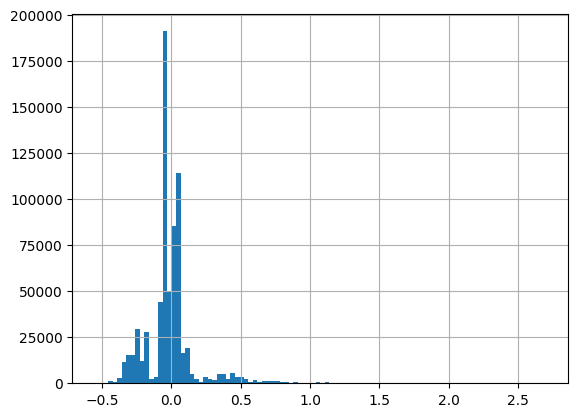

In [9]:
import matplotlib.pyplot as plt
trn_df[TARGET].hist(bins=100)

In [10]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [11]:
import torch
import torch.nn as nn

class PitchValueNet(nn.Module):
    def __init__(self, n_pitch_types, emb_dim, n_continuous):
        super().__init__()
        
        # two separate embedding tables
        self.emb_current  = nn.Embedding(n_pitch_types, emb_dim)
        self.emb_previous = nn.Embedding(n_pitch_types, emb_dim)
        
        # MLP input dim = emb_dim + emb_dim + n_continuous
        mlp_input_dim = emb_dim * 2 + n_continuous
        
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x_cont, x_pitch_type, x_prev_pitch_type):
        emb1 = self.emb_current(x_pitch_type)
        emb2 = self.emb_previous(x_prev_pitch_type)
   
        x = torch.cat([emb1, emb2, x_cont], dim=1)
        return self.mlp(x)

In [12]:
scaler = RobustScaler()
X_cont_train_scaled = scaler.fit_transform(X_train[CONT_COLS])
X_cont_test_scaled  = scaler.transform(X_test[CONT_COLS])

X_cont_train   = torch.tensor(X_cont_train_scaled, dtype=torch.float32)
X_cont_test    = torch.tensor(X_cont_test_scaled,  dtype=torch.float32)
X_pitch_train  = torch.tensor(X_train['pitch_type_enc'].values, dtype=torch.long)
X_pitch_test   = torch.tensor(X_test['pitch_type_enc'].values,  dtype=torch.long)
X_prev_train   = torch.tensor(X_train['prev_pitch_type_enc'].values, dtype=torch.long)
X_prev_test    = torch.tensor(X_test['prev_pitch_type_enc'].values,  dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values,  dtype=torch.float32)

dataloader = DataLoader(
    TensorDataset(X_cont_train, X_pitch_train, X_prev_train, y_train_tensor),
    batch_size=512, shuffle=True,
)
test_dataloader = DataLoader(
    TensorDataset(X_cont_test, X_pitch_test, X_prev_test, y_test_tensor),
    batch_size=512, shuffle=False,
)

n_pitch_types = len(le.classes_)
model = PitchValueNet(n_pitch_types=n_pitch_types, emb_dim=9, n_continuous=len(CONT_COLS)).to(device)
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_cont_b, X_pitch_b, X_prev_b, y_b in loader:
        X_cont_b, X_pitch_b, X_prev_b, y_b = (
            X_cont_b.to(device), X_pitch_b.to(device), X_prev_b.to(device), y_b.to(device)
        )
        optimizer.zero_grad()
        loss = criterion(model(X_cont_b, X_pitch_b, X_prev_b).squeeze(), y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_b)
    return total_loss / len(loader.dataset)


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_cont_b, X_pitch_b, X_prev_b, y_b in loader:
            X_cont_b, X_pitch_b, X_prev_b, y_b = (
                X_cont_b.to(device), X_pitch_b.to(device), X_prev_b.to(device), y_b.to(device)
            )
            total_loss += criterion(model(X_cont_b, X_pitch_b, X_prev_b).squeeze(), y_b).item() * len(y_b)
    return total_loss / len(loader.dataset)


for epoch in range(10):
    train_loss = train_one_epoch(model, dataloader,      optimizer, criterion, device)
    val_loss   = eval_one_epoch( model, test_dataloader, criterion, device)
    print(f"Epoch {epoch+1:2d}: train={train_loss:.4f}  val={val_loss:.4f}")

Epoch  1: train=0.0520  val=0.0530
Epoch  2: train=0.0513  val=0.0524
Epoch  3: train=0.0512  val=0.0525
Epoch  4: train=0.0511  val=0.0522
Epoch  5: train=0.0511  val=0.0522
Epoch  6: train=0.0510  val=0.0522
Epoch  7: train=0.0510  val=0.0522
Epoch  8: train=0.0510  val=0.0524
Epoch  9: train=0.0510  val=0.0521
Epoch 10: train=0.0509  val=0.0521


In [14]:
test_df[['pitcher', 'pred_xrv']].groupby('pitcher').mean().reset_index().sort_values('pred_xrv', ascending=False)

NameError: name 'test_df' is not defined

In [ ]:
from scipy.stats import spearmanr
import pybaseball

# Step 1: get pitch-level predictions on test set
model.eval()
with torch.no_grad():
    test_preds = model(X_cont_test, X_pitch_test, X_prev_test).squeeze().numpy()

# Step 2: attach predictions back to test dataframe
test_df = test.copy()
test_df['pred_xrv'] = test_preds

# Step 3: aggregate to pitcher level
# YOUR TASK: aggregate pred_xrv to pitcher level
# hint: lower mean xRV = better pitcher (fewer runs allowed)
# what column in statcast_df identifies the pitcher?
pitcher_xrv = test_df[['pitcher', 'pred_xrv']].groupby('pitcher').mean().reset_index()

# Step 4: pull Stuff+ from FanGraphs
# hint: pybaseball.pitching_stats() — what arguments do you need?
stuff_plus = pybaseball.pitching_stats(2023, qual=50) 

# Step 5: merge and correlate
# YOUR TASK: merge pitcher_xrv with stuff_plus and compute spearmanr

In [ ]:
IDmlbam = pitcher_xrv['pitcher'].unique()
lookup_df = playerid_reverse_lookup(IDmlbam)[['key_mlbam', 'key_fangraphs']]
lookup_pitcher = lookup_df.rename(columns={'key_fangraphs': 'IDfg', 'key_mlbam': 'pitcher'})

stuff_plus_subset = stuff_plus[['IDfg', 'Stuff+']]
merged = pitcher_xrv.merge(lookup_pitcher, on='pitcher', how='left').merge(stuff_plus_subset, on='IDfg', how='left')

In [ ]:
from scipy.stats import spearmanr

# drop any pitchers who didn't match to FanGraphs
merged_clean = merged.dropna(subset=['Stuff+'])

corr, pval = spearmanr(merged_clean['pred_xrv'], merged_clean['Stuff+'])
print(f"Spearman r = {corr:.3f}, p-value = {pval:.4f}")

Spearman r = -0.381, p-value = 0.0000


In [ ]:
# impute location and sequencing columns with 0 (post-scaling mean)
LOCATION_COLS = ['plate_x', 'plate_z', 'zone']
SEQUENCING_COLS = ['pitch_number']  # prev_pitch_type handled separately

cont_col_indices = {col: i for i, col in enumerate(CONT_COLS)}

X_cont_test_ablated = X_cont_test.clone()

# zero out location cols
for col in LOCATION_COLS + SEQUENCING_COLS:
    idx = cont_col_indices[col]
    X_cont_test_ablated[:, idx] = 0.0

# for prev_pitch_type — what value would you use to represent "no sequencing info"?
start_idx = le.transform(['START'])[0]
X_prev_test_ablated = torch.full_like(X_prev_test, start_idx)

In [ ]:
model.eval()
with torch.no_grad():
    test_preds_ablated = model(
        X_cont_test_ablated, 
        X_pitch_test,          # pitch type unchanged
        X_prev_test_ablated    # sequencing neutralized
    ).squeeze().numpy()

test_df['pred_xrv_ablated'] = test_preds_ablated

pitcher_xrv_ablated = test_df.groupby('pitcher')['pred_xrv_ablated'].mean().reset_index()

merged_ablated = pitcher_xrv_ablated.merge(lookup_pitcher, on='pitcher', how='left').merge(stuff_plus_subset, on='IDfg', how='left').dropna(subset=['Stuff+'])

corr_ablated, pval_ablated = spearmanr(merged_ablated['pred_xrv_ablated'], merged_ablated['Stuff+'])
print(f"Ablated Spearman r = {corr_ablated:.3f}, p-value = {pval_ablated:.4f}")

Ablated Spearman r = -0.368, p-value = 0.0000


In [ ]:
# pull SIERA from FanGraphs — already in pitching_stats
siera_subset = stuff_plus[['IDfg', 'SIERA']]

# YOUR TASK:
# 1. merge pitcher_xrv (full model) with SIERA
merged_siera = pitcher_xrv.merge(lookup_pitcher, on='pitcher', how='left').merge(siera_subset, on='IDfg', how='left').dropna(subset=['SIERA'])
# 2. merge pitcher_xrv_ablated with SIERA  
merged_siera_ablated = pitcher_xrv_ablated.merge(lookup_pitcher, on='pitcher', how='left').merge(siera_subset, on='IDfg', how='left').dropna(subset=['SIERA'])
# 3. compute spearmanr for both
corr_siera, pval_siera = spearmanr(merged_siera['pred_xrv'], merged_siera['SIERA'])
corr_siera_ablated, pval_siera_ablated = spearmanr(merged_siera_ablated['pred_xrv_ablated'], merged_siera_ablated['SIERA'])
# 4. compare all four correlations in a summary table
print(f"Full Model vs SIERA: Spearman r = {corr_siera:.3f}, p-value = {pval_siera:.4f}")
print(f"Ablated Model vs SIERA: Spearman r = {corr_siera_ablated:.3f}, p-value = {pval_siera_ablated:.4f}")

Full Model vs SIERA: Spearman r = 0.430, p-value = 0.0000
Ablated Model vs SIERA: Spearman r = 0.349, p-value = 0.0000


# Stage 2: Exponential Decay

In [17]:
import numpy as np

# first get full season predictions
# YOUR TASK: generate pred_xrv for the full dataset (not just test)
# hint: you need to build tensors from trn_df the same way as before

trn_df['game_date'] = pd.to_datetime(trn_df['game_date'])

X_full = trn_df[FEATURES]
y_full = trn_df[TARGET]

X_cont_full_scaled  = scaler.transform(X_full[CONT_COLS])

X_cont_full    = torch.tensor(X_cont_full_scaled,  dtype=torch.float32, device=device)
X_pitch_full  = torch.tensor(X_full['pitch_type_enc'].values, dtype=torch.long, device=device)
X_prev_full   = torch.tensor(X_full['prev_pitch_type_enc'].values, dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    pred_xrv_full = model(X_cont_full, X_pitch_full, X_prev_full).squeeze().cpu().numpy()

trn_df['pred_xrv'] = pred_xrv_full

# then compute exponential decay weighted mean per pitcher as of a given date T
def pitcher_score(df, pitcher_id, as_of_date, lam=0.046):
    """
    df: full dataframe with pred_xrv and game_date
    returns: exponentially weighted mean xRV for pitcher as of date T
    """
    pitcher_df = df[df['pitcher'] == pitcher_id].copy()
    pitcher_df = pitcher_df[pitcher_df['game_date'] <= as_of_date]
    
    T = pd.Timestamp(as_of_date)
    
    pitcher_df['days_ago'] = (T - pitcher_df['game_date']).dt.days
    pitcher_df['weight']   = np.exp(-lam * pitcher_df['days_ago'])
    
    weighted_xrv = (pitcher_df['weight'] * pitcher_df['pred_xrv']).sum() / pitcher_df['weight'].sum()
    return weighted_xrv

In [18]:
def pitcher_leaderboard(df, as_of_date, min_pitches=100, lam=0.046):
    """
    Returns ranked dataframe of all pitchers as of a given date
    min_pitches: minimum pitch count to filter small samples
    """
    # filter to pitchers with enough pitches up to as_of_date
    eligible = (
        df[df['game_date'] <= as_of_date]
        .groupby('pitcher')['pred_xrv']
        .count()
        .reset_index()
        .rename(columns={'pred_xrv': 'pitch_count'})
    )
    eligible = eligible[eligible['pitch_count'] >= min_pitches]
    
    # YOUR TASK: compute pitcher_score for each eligible pitcher
    # then sort — which direction? ascending or descending?
    eligible['weighted_xrv'] = eligible['pitcher'].apply(lambda pid: pitcher_score(df, pid, as_of_date, lam))
    
    return eligible.sort_values('weighted_xrv', ascending=True)

In [28]:
leaderboard = pitcher_leaderboard(trn_df, as_of_date='2023-08-01')

top5_ids = leaderboard.head(5)['pitcher'].values
playerid_reverse_lookup(top5_ids)[['key_mlbam', 'name_first', 'name_last']]

,key_mlbam,name_first,name_last


In [37]:
# classify SP vs RP based on median pitches per appearance
pitcher_appearance = (
    trn_df.groupby(['pitcher', 'game_pk'])['pitch_number']
    .count()
    .reset_index()
    .rename(columns={'pitch_number': 'pitches_in_game'})
)

pitcher_type = (
    pitcher_appearance.groupby('pitcher')['pitches_in_game']
    .median()
    .reset_index()
    .rename(columns={'pitches_in_game': 'median_pitches'})
)

pitcher_type['role'] = pitcher_type['median_pitches'].apply(
    lambda x: 'SP' if x >= 50 else 'RP'
)

# merge back to trn_df
trn_df = trn_df.merge(pitcher_type[['pitcher', 'role']], on='pitcher', how='left')

In [25]:
def pitcher_leaderboard(df, as_of_date, role='SP', min_pitches=100, lam=0.046):
    eligible = (
        df[(df['game_date'] <= as_of_date) & (df['role'] == role)]
        .groupby('pitcher')['pred_xrv']
        .count()
        .reset_index()
        .rename(columns={'pred_xrv': 'pitch_count'})
    )
    eligible = eligible[eligible['pitch_count'] >= min_pitches]
    
    # YOUR TASK: compute pitcher_score for each eligible pitcher
    # then sort — which direction? ascending or descending?
    eligible['weighted_xrv'] = eligible['pitcher'].apply(lambda pid: pitcher_score(df, pid, as_of_date, lam))
    
    return eligible.sort_values('weighted_xrv', ascending=True)

In [38]:
leaderboard = pitcher_leaderboard(trn_df, as_of_date='2023-08-01', role = 'SP')

top10_ids = leaderboard.head(10)['pitcher'].values
playerid_reverse_lookup(top10_ids)[['key_mlbam', 'name_first', 'name_last']]

,key_mlbam,name_first,name_last
0,669373,tarik,skubal
1,676272,bobby,miller
2,656876,drew,rasmussen
3,694297,brandon,pfaadt
4,607192,tyler,glasnow
5,666159,matt,manning
6,594798,jacob,degrom
7,592332,kevin,gausman
8,554430,zack,wheeler
9,605488,jeffrey,springs


In [39]:
leaderboard = pitcher_leaderboard(trn_df, as_of_date='2023-08-01', role = 'RP')

top10_ids = leaderboard.head(10)['pitcher'].values
playerid_reverse_lookup(top10_ids)[['key_mlbam', 'name_first', 'name_last']]

,key_mlbam,name_first,name_last
0,666619,gregory,santos
1,592779,brock,stewart
2,656546,jeff,hoffman
3,592741,chasen,shreve
4,640448,kyle,finnegan
5,519151,ryan,pressly
6,641729,joe,jiménez
7,445276,kenley,jansen
8,547973,aroldis,chapman
9,661403,emmanuel,clase


In [40]:
import pandas as pd
import numpy as np

# generate weekly snapshots throughout the season
as_of_dates = pd.date_range(start='2023-04-01', end='2023-09-30', freq='W')

# YOUR TASK: for a given pitcher_id, compute weighted_xrv at each date
# and return a time series dataframe

def pitcher_trajectory(df, pitcher_id, dates, lam=0.046):
    records = []
    for date in dates:
        # filter to minimum pitch count before scoring
        pitch_count = len(df[(df['pitcher'] == pitcher_id) & 
                             (df['game_date'] <= date)])
        if pitch_count >= 100:
            score = pitcher_score(df, pitcher_id, date, lam)
            records.append({'date': date, 'weighted_xrv': score})
    
    return pd.DataFrame(records)

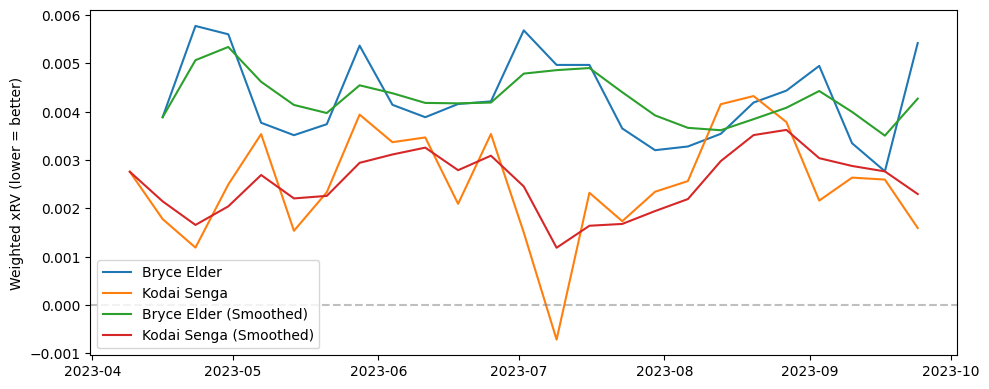

In [42]:
import matplotlib.pyplot as plt

# look up IDs
names = [('elder', 'bryce'), ('senga', 'kodai')]
# use playerid_lookup to get MLBAM IDs
from pybaseball import playerid_lookup

elder_id = playerid_lookup('elder', 'bryce')['key_mlbam'].values[0]
senga_id = playerid_lookup('senga', 'kodai')['key_mlbam'].values[0]

# compute trajectories
elder_traj = pitcher_trajectory(trn_df, elder_id, as_of_dates)
senga_traj = pitcher_trajectory(trn_df, senga_id, as_of_dates)

elder_traj['smoothed_xrv'] = elder_traj['weighted_xrv'].ewm(span=4).mean()
senga_traj['smoothed_xrv'] = senga_traj['weighted_xrv'].ewm(span=4).mean()

# plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(elder_traj['date'], elder_traj['weighted_xrv'], label='Bryce Elder')
ax.plot(senga_traj['date'], senga_traj['weighted_xrv'], label='Kodai Senga')
ax.plot(elder_traj['date'], elder_traj['smoothed_xrv'], label='Bryce Elder (Smoothed)')
ax.plot(senga_traj['date'], senga_traj['smoothed_xrv'], label='Kodai Senga (Smoothed)')
ax.axhline(0, linestyle='--', color='gray', alpha=0.5)
ax.set_ylabel('Weighted xRV (lower = better)')
ax.legend()
plt.tight_layout()
plt.show()

---
# Bayesian Neural Net

In [ ]:
import pyro
import pyro.distributions as dist

def model(pitcher_ids, appearance_xrv, appearance_weights, n_pitchers):
    # hyperpriors — league level
    mu_league    = pyro.sample('mu_league', dist.Normal(0, 0.01))
    sigma_league = pyro.sample('sigma_league', dist.HalfNormal(0.01))
    sigma_noise  = pyro.sample('sigma_noise', dist.HalfNormal(0.01))
    
    # pitcher level — partial pooling
    with pyro.plate('pitchers', n_pitchers):
        mu_pitcher = pyro.sample('mu_pitcher', dist.Normal(mu_league, sigma_league))
    
    # observation level
    with pyro.plate('appearances', len(appearance_xrv)):
        pyro.sample('obs', dist.Normal(mu_pitcher[pitcher_ids], sigma_noise / appearance_weights), 
                    obs=appearance_xrv)